# **WSINDy for ODEs: Examples**

- Based on the [JCP paper by **D. A. Messenger**, **D. M. Bortz** (2021)](https://www.sciencedirect.com/science/article/pii/S0021999121004204).
- See the authors' original [MatLab code repository](https://github.com/MathBioCU/WSINDy_PDE).

Seth Minor, 2025

---

This notebook illustrates the Weak SINDy algorithm being applied to various ODE systems:
- the logistic equation
- the Lotka-Volterra equations
- the Lorenz '63 equations

In [1]:
import sys
sys.path.append('../src')

import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from IPython.display import display,Math

from wsindy import *

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

In [2]:
# Plot settings
import matplotlib

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
#plt.rcParams['figure.dpi'] = 300

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

Utilities and helpers...

In [3]:
def to_torch_solution(sol):
  return [torch.tensor(ui, dtype=torch.float64) for ui in sol.y]

def add_noise_to_states(states, noise):
  if noise == 0:
    return states
  return [add_noise(ui, noise) for ui in states]

def plot_states(t, states, names, title):
  plt.figure(figsize=(7,3))
  for ui,name in zip(states,names):
    plt.plot(t, ui, label='$' + name + '(t)$')
  plt.xlabel('$t$')
  plt.title(title)
  plt.grid(True, alpha=0.3)
  plt.legend(loc='upper left')
  plt.show()

def fit_wsindy_ode(Ui, V, local_names, t, beta, m, p, s, Lambda, rescale=True, verbosity=False):
  alpha = [[1], [0]]
  model = WSINDy(Ui, alpha, beta, t, V=V, names=local_names, m=m, p=p, s=s,
                 verbosity=verbosity, rescale=rescale, eqn_type='ode')
  [G,powers,derivs,rhs_names] = model.create_default_library()
  model.build_lhs(local_names[0] + model.derivative_names[0])
  model.set_library(G, powers, derivs, rhs_names)
  _ = model.MSTLS(Lambda=Lambda)
  return model

def fit_wsindy_system(states, t, names, beta, m, p, s, Lambda=1e-3, rescale=True, verbosity=False):
  models = []
  odes = []

  for i,Ui in enumerate(states):
    aux_inds = [j for j in range(len(states)) if j != i]
    V = [states[j] for j in aux_inds]
    local_names = [names[i]] + [names[j] for j in aux_inds]

    model = fit_wsindy_ode(Ui, V, local_names, t, beta, m, p, s, Lambda, rescale, verbosity)
    display(Math(r'\Theta_{' + names[i] + r'}=' + r'\{' + r', \, '.join(model.rhs_names) + r'\}'))
    model.print_report()

    models.append(model)
    odes.append(symbolic_eqn(model.lhs_name, model.rhs_names, model.coeffs))

  for ode in odes:
    display(Math(ode))
  return models,odes

def check_recovery(model, truth, tol=0.1):
  got = {name: c for name,c in zip(model.rhs_names, model.coeffs.tolist()) if c != 0}
  assert set(got) == set(truth), f'Support mismatch: {got}'
  for name,c in truth.items():
    assert abs(got[name] - c)/abs(c) < tol, f'{name}: {got[name]:.4f} vs {c}'
  print('Verified: ' + ', '.join(f'{name} = {got[name]:.4f} (true {c:g})' for name,c in truth.items()))

## **LOGISTIC EQUATION**

This example uses:
\begin{align*}
  \dot u = r u\left(1 - \frac{u}{\kappa}\right) = ru - \left(\frac{r}{\kappa}\right) u^2,
  \quad \text{with} \quad
  \begin{cases}
    r = 1.5,
    \\
    K=2.
  \end{cases}
\end{align*}

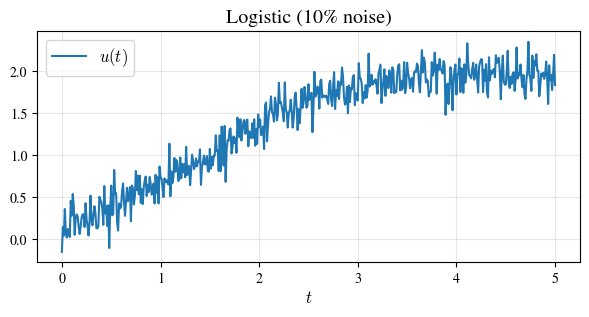

In [4]:
r = 1.5
kappa = 2.0
t_np = np.linspace(0, 5, 501)

def logistic_rhs(t, u):
  return r*u*(1 - u/kappa)

sol = solve_ivp(logistic_rhs, (t_np[0], t_np[-1]), [0.2], t_eval=t_np, rtol=1e-12, atol=1e-12, method='DOP853')

noise = 0.10
t = torch.tensor(t_np, dtype=torch.float64)
logistic_clean = to_torch_solution(sol)
torch.manual_seed(0)
[u] = add_noise_to_states(logistic_clean, noise)

plot_states(t_np, [u], ['u'], f'Logistic ({noise*100:.0f}% noise)')

In [5]:
beta = [[0], [1], [2]]

[models, odes] = fit_wsindy_system([u], t, ['u'], beta, m=[16], p=[8], s=[5], Lambda=1e-1)
check_recovery(models[0], {'(u)': 1.5, '(u^2)': -0.75}, tol=0.1)

100%|██████████| 1/1 [00:00<00:00, 717.47it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [16]
p = [8]
s = [5]
yt = 6.250
yu = 0.741
Aux. scales = []

LIBRARY
Num. query points = 94
Num. terms = 3
cond(G) = 3.275e+01

RESULTS
ODE: u_{t} = + 1.50(u) - 0.75(u^2)
Nonzero terms = 2
Rel. L2 error = 0.845
R^2 = 0.118
Lambda = 1.000e-01
Loss = 0.674


<IPython.core.display.Math object>

Verified: (u) = 1.4986 (true 1.5), (u^2) = -0.7458 (true -0.75)


## **LOTKA-VOLTERRA**

This pup is:
\begin{align*}
  \begin{cases}
    \dot{x} = +ax - bxy,\\
    \dot{y} = -cy + dxy,
  \end{cases}
  \quad \text{with} \quad
  \begin{cases}
    a = 1.5,
    \\
    b = 1,
    \\
    c = 3,
    \\
    d = 1.
  \end{cases}
\end{align*}

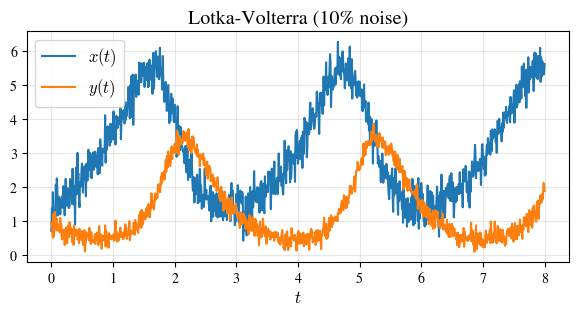

In [6]:
a, b, c, d = 1.5, 1.0, 3.0, 1.0
t_np = np.linspace(0, 8, 1001)

def lotka_volterra_rhs(t, z):
  x,y = z
  return [a*x - b*x*y,
          -c*y + d*x*y]

sol = solve_ivp(lotka_volterra_rhs, (t_np[0], t_np[-1]), [1.5, 1.0], t_eval=t_np,
                rtol=1e-12, atol=1e-12, method='DOP853')

noise = 0.10
t = torch.tensor(t_np, dtype=torch.float64)
lv_clean = to_torch_solution(sol)
torch.manual_seed(0)
[x,y] = add_noise_to_states(lv_clean, noise)

plot_states(t_np, [x,y], ['x','y'], f'Lotka-Volterra ({noise*100:.0f}% noise)')

In [7]:
beta = [[0,0],
        [1,0],
        [0,1],
        [2,0],
        [1,1],
        [0,2]]

[models, odes] = fit_wsindy_system([x,y], t, ['x','y'], beta, m=[20], p=[10], s=[5], Lambda=1e-1)
check_recovery(models[0], {'(x)': 1.5, '(x y)': -1.0}, tol=0.1)
check_recovery(models[1], {'(y)': -3.0, '(y x)': 1.0}, tol=0.1)

100%|██████████| 1/1 [00:00<00:00, 638.01it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [5]
yt = 6.250
yu = 0.473
Aux. scales = [0.608]

LIBRARY
Num. query points = 193
Num. terms = 6
cond(G) = 1.546e+02

RESULTS
ODE: x_{t} = + 1.50(x) - 0.99(x y)
Nonzero terms = 2
Rel. L2 error = 0.496
R^2 = 0.749
Lambda = 1.000e-01
Loss = 0.358


100%|██████████| 1/1 [00:00<00:00, 667.25it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [5]
yt = 6.250
yu = 0.608
Aux. scales = [0.473]

LIBRARY
Num. query points = 193
Num. terms = 6
cond(G) = 1.546e+02

RESULTS
ODE: y_{t} = - 3.03(y) + 1.00(y x)
Nonzero terms = 2
Rel. L2 error = 0.340
R^2 = 0.885
Lambda = 1.000e-01
Loss = 0.357


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Verified: (x) = 1.4957 (true 1.5), (x y) = -0.9897 (true -1)
Verified: (y) = -3.0273 (true -3), (y x) = 1.0011 (true 1)


## **LORENZ '63**

The all-time classic:
\begin{align*}
  \begin{cases}
    \dot{x} = \sigma(y-x),\\
    \dot{y} = x(\rho-z)-y,\\
    \dot{z} = xy-\beta z,
  \end{cases}
  \quad \text{with} \quad
  \begin{cases}
    \sigma = 10,
    \\
    \rho = 28,
    \\
    \beta = 8/3.
  \end{cases}
\end{align*}

For each state equation below, the library is ordered with the left-hand-side state first and the remaining states as auxiliaries.

*Note:* at $5\%$ noise with $\lambda = 10^{-1}$, MSTLS thresholds out the small $-y$ term in $\dot y$ (its magnitude is $28\times$ smaller than the $\rho x$ term). Using $1\%$ noise and $\lambda = 10^{-2}$ recovers the full system.

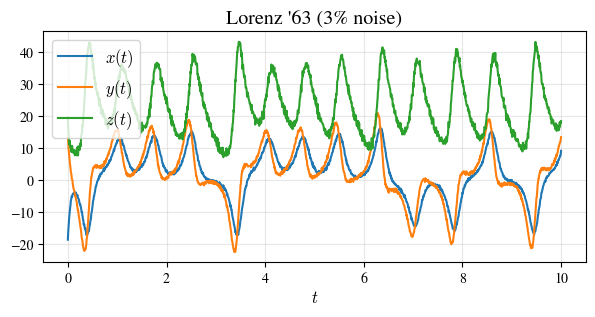

In [8]:
sigma = 10.0
rho = 28.0
beta_param = 8/3
t_np = np.linspace(0, 10, 1501)

def lorenz_rhs(t, z):
  x,y,z0 = z
  return [sigma*(y - x),
          x*(rho - z0) - y,
          x*y - beta_param*z0]

#sol = solve_ivp(lorenz_rhs, (t_np[0], t_np[-1]), [-8.0, 8.0, 27.0], t_eval=t_np, rtol=1e-12, atol=1e-12, method='DOP853')
sol = solve_ivp(lorenz_rhs, (t_np[0], t_np[-1]), [-18.1, 13.0, 18.0], t_eval=t_np, rtol=1e-12, atol=1e-12, method='DOP853')

noise = 0.03
t = torch.tensor(t_np, dtype=torch.float64)
lorenz_clean = to_torch_solution(sol)
torch.manual_seed(0)
[x,y,z] = add_noise_to_states(lorenz_clean, noise)

plot_states(t_np, [x,y,z], ['x','y','z'], f"Lorenz '63 ({noise*100:.0f}% noise)")

In [9]:
beta = [[0,0,0],
        [1,0,0],
        [0,1,0],
        [0,0,1],
        [2,0,0],
        [1,1,0],
        [1,0,1],
        [0,2,0],
        [0,1,1],
        [0,0,2]]

[models, odes] = fit_wsindy_system([x,y,z], t, ['x','y','z'], beta, m=[16], p=[12], s=[1], Lambda=1e-2)
check_recovery(models[0], {'(x)': -10.0, '(y)': 10.0}, tol=0.05)
check_recovery(models[1], {'(x)': 28.0, '(y)': -1.0, '(x z)': -1.0}, tol=0.05)
check_recovery(models[2], {'(z)': -8/3, '(x y)': 1.0}, tol=0.05)

100%|██████████| 1/1 [00:00<00:00, 466.76it/s]


<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [16]
p = [12]
s = [1]
yt = 9.375
yu = 0.285
Aux. scales = [0.254, 0.18]

LIBRARY
Num. query points = 1469
Num. terms = 10
cond(G) = 5.065e+02

RESULTS
ODE: x_{t} = - 9.99(x) + 9.99(y)
Nonzero terms = 2
Rel. L2 error = 0.059
R^2 = 0.997
Lambda = 1.000e-02
Loss = 0.209


100%|██████████| 1/1 [00:00<00:00, 388.18it/s]


<IPython.core.display.Math object>

...

HYPER-PARAMETERS
m = [16]
p = [12]
s = [1]
yt = 9.375
yu = 0.180
Aux. scales = [0.285, 0.254]

LIBRARY
Num. query points = 1469
Num. terms = 10
cond(G) = 5.065e+02

RESULTS
ODE: z_{t} = - 2.66(z) + 1.00(x y)
Nonzero terms = 2
Rel. L2 error = 0.087
R^2 = 0.992
Lambda = 1.000e-02
Loss = 0.208


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Verified: (x) = -9.9930 (true -10), (y) = 9.9894 (true 10)
Verified: (x) = 27.8238 (true 28), (y) = -0.9763 (true -1), (x z) = -0.9947 (true -1)
Verified: (z) = -2.6645 (true -2.66667), (x y) = 1.0003 (true 1)


## **HYPERPARAMETER SWEEPS**

The `hyperparameter_sweep` method probes model recovery over a grid of MSTLS thresholds $\lambda$, test function support radii $m$, and `rescale` on/off (using `s=1`, i.e. the maximum number of query points). Each row of the returned dictionary records the identified model, its nonzero terms and coefficients, and validation metrics (sparsity, MSTLS loss, $R^2$, relative $L^2$ residual, $\kappa(G)$); `csv_path` optionally saves the table, and passing a ground-truth `truth` dictionary adds a maximum relative coefficient error column ($E_\infty$, with dropped terms counted as zero coefficients). By default, `m_values` scales the base model's $m$ by factors $\{0.5, 0.75, 1, 1.25, 1.5\}$ and `Lambdas` uses the same 50-point grid scanned by `MSTLS`.

The heatmaps show sparsity, $R^2$, and $\log_{10}$ coefficient error over the $m$–$\lambda$ plane: a wide plateau at the true model size with $R^2 \approx 1$ marks the stable recovery region.

100%|██████████| 21/21 [00:05<00:00,  3.99it/s]


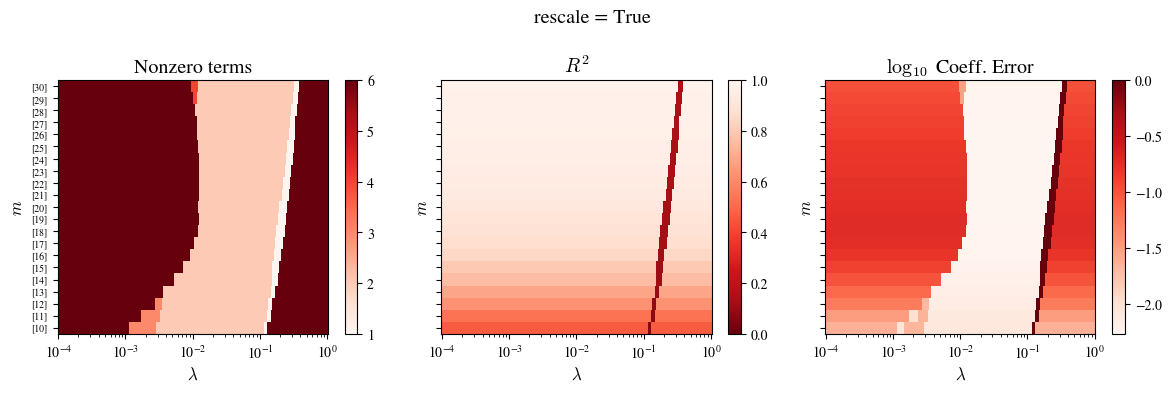

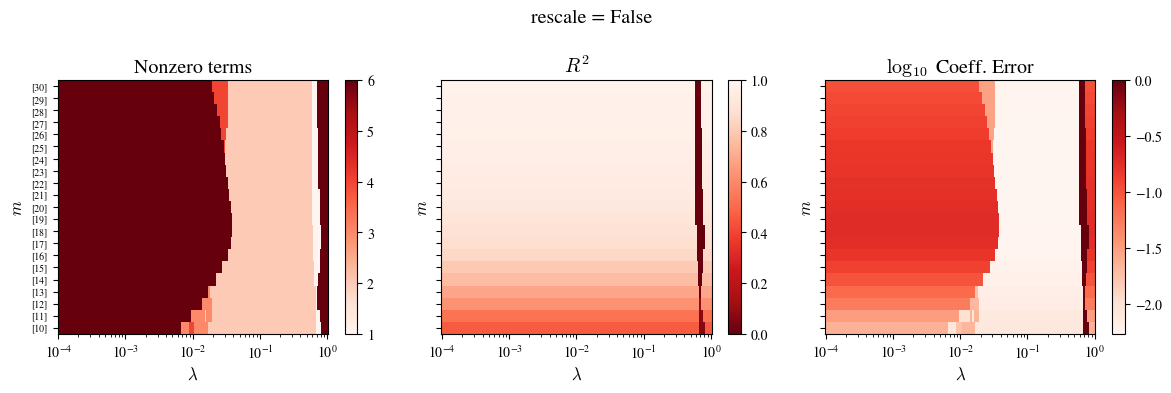

In [16]:
# Lotka-Volterra x-equation at 5% noise, default m and Lambda grids
t = torch.tensor(np.linspace(0, 8, 1001))
torch.manual_seed(0)
[x,y] = add_noise_to_states(lv_clean, 0.05)

beta = [[0,0],
        [1,0],
        [0,1],
        [2,0],
        [1,1],
        [0,2]]

model = WSINDy(x, [[1],[0]], beta, t, V=[y], names=['x','y'], m=[20], p=[10], s=[1],
               verbosity=False, eqn_type='ode')
truth = {'(x)': 1.5, '(x y)': -1.0}
results = model.hyperparameter_sweep(lhs_name='x_{t}', truth=truth)

In [17]:
# Most common models across the sweep
from collections import Counter

for model_str,count in Counter(results['model']).most_common(4):
  print(f'{count:3d}/{len(results["model"])} fits: {model_str}')

1760/8400 fits: x_{t} = + 1.50(x) - 0.99(x y)
1043/8400 fits: x_{t} = + 1.49(x) - 0.99(x y)
541/8400 fits: x_{t} = + 0.58(1) + 1.22(x) - 0.34(y) + 0.04(x^2) - 0.98(x y) + 0.08(y^2)
534/8400 fits: x_{t} = + 0.55(1) + 1.24(x) - 0.33(y) + 0.04(x^2) - 0.98(x y) + 0.07(y^2)


100%|██████████| 17/17 [00:05<00:00,  3.18it/s]


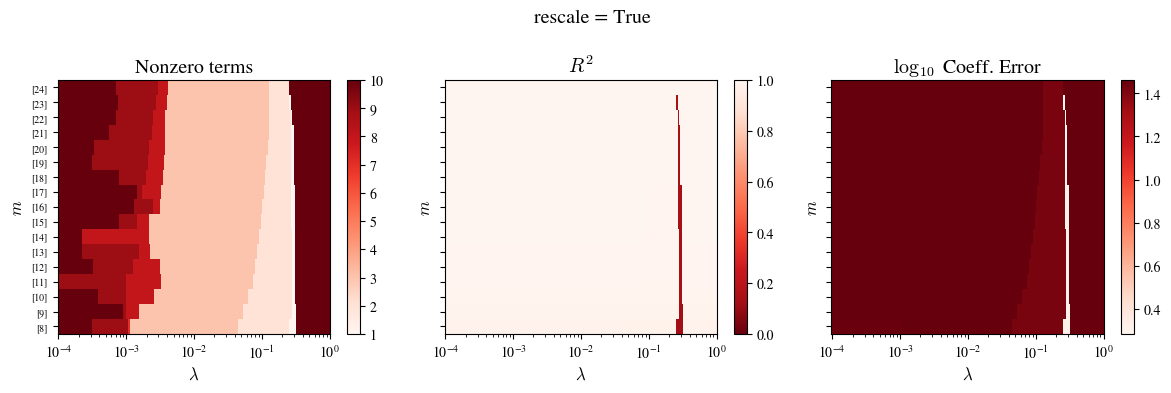

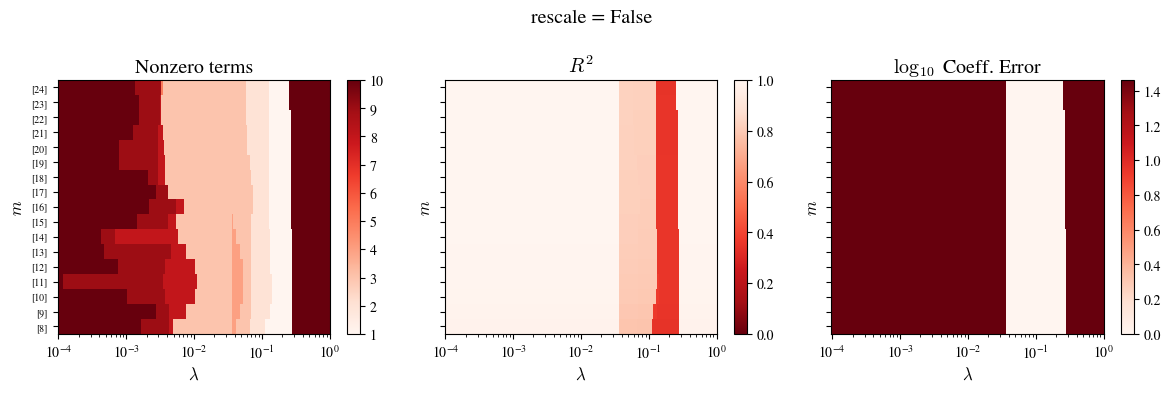

In [26]:
# Lorenz '63 x-equation at 3% noise
t = torch.tensor(np.linspace(0, 10, 1501))
torch.manual_seed(0)
[x,y,z] = add_noise_to_states(lorenz_clean, 0.03)

beta = [[0,0,0],
        [1,0,0],
        [0,1,0],
        [0,0,1],
        [2,0,0],
        [1,1,0],
        [1,0,1],
        [0,2,0],
        [0,1,1],
        [0,0,2]]

# model = WSINDy(x, [[1],[0]], beta, t, V=[y,z], names=['x','y','z'], m=[16], p=[12], s=[1], verbosity=False, eqn_type='ode')
# truth = {'(x)': -10.0, '(y)': 10.0}
# results = model.hyperparameter_sweep(lhs_name='x_{t}', truth=truth)
model = WSINDy(y, [[1],[0]], beta, t, V=[x,z], names=['x','y','z'], m=[16], p=[12], s=[1], verbosity=False, eqn_type='ode')
truth = {'(x)': 28.0, '(y)': -1.0, '(x z)': -1.0}
results = model.hyperparameter_sweep(lhs_name='y_{t}', truth=truth)

#check_recovery(models[2], {'(z)': -8/3, '(x y)': 1.0}, tol=0.05)

In [14]:
# # Kuramoto Sivashinsky at 20% noise, reduced Lambda grid, results saved to CSV
# U = torch.tensor(np.loadtxt('../data/KS.txt', delimiter=','))
# torch.manual_seed(0)
# U = add_noise(U, 0.2).view(256, -1)
# x = torch.linspace(0, 32*np.pi, 256)
# t = torch.linspace(0, 150, 301)

# alpha = [[0,1],
#          [0,0],
#          [1,0],
#          [2,0],
#          [3,0],
#          [4,0]]

# beta = [[0],
#         [1],
#         [2]]

# model = WSINDy(U, alpha, beta, [x,t], m=[18,30], verbosity=False, eqn_type='pde')
# truth = {'(u^2)_{x}': -0.5, '(u)_{xx}': -1.0, '(u)_{xxxx}': -1.0}
# Lambdas = 10**((4/19)*torch.arange(0,20)-4)
# results = model.hyperparameter_sweep(lhs_name='u_{t}', Lambdas=Lambdas, truth=truth, csv_path='ks_sweep.csv')

# for model_str,count in Counter(results['model']).most_common(4):
#   print(f'{count:3d}/{len(results["model"])} fits: {model_str}')